# Детекция меланомы | Часть 4: Поиск гиперпараметров и обучение Swin Transformer

| | |
|---|---|
| **Датасет** | ISIC 2020 (33 126 изображений, менее 2% меланом) |
| **Задача** | Бинарная классификация: меланома / доброкачественное |
| **Архитектура** | Swin-Base/4-7 pretrained ImageNet-22k → ImageNet-1k, full fine-tuning |
| **Главная метрика** | AUC-PR (Average Precision) |
| **Вспомогательные** | F1, Recall, Precision, Specificity, Balanced Accuracy |

---

## Структура ноутбука

Поиск лучших гиперпараметров ведётся автоматически через Optuna, затем лучшие конфигурации дообучаются на большем числе эпох.

| Блок | Что делается | Эпох |
|---|---|---|
| **1. Optuna** | Автоматический поиск гиперпараметров: оптимизатор, планировщик, lr, weight decay, dropout, label smoothing | 15 × 15 trials |
| **2. Топ-3** | Три лучшие конфигурации обучаются полноценно, сохраняются веса и метрики | 30 |
| **3. Финал** | Лучшая модель дообучается с early stopping (patience=7) | 50 |

## 1. Конфигурация и импорты

In [1]:
import os
import json
import random
import shutil
import time
import copy

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms

import timm  # библиотека с предобученным Swin Transformer

from sklearn.metrics import (
    average_precision_score,
    f1_score,
    recall_score,
    precision_score,
    balanced_accuracy_score,
    confusion_matrix,
)

import optuna
from optuna.pruners import MedianPruner

from torch.cuda.amp import autocast, GradScaler

import IPython.display as ipd

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [3]:
# Пути к данным
IMAGE_DIR = "/kaggle/input/datasets/cdeotte/jpeg-melanoma-256x256/train"
TRAIN_CSV  = '/kaggle/input/datasets/sitnikovadarya/splitsss/split_train.csv'
VAL_CSV    = '/kaggle/input/datasets/sitnikovadarya/splitsss/split_val.csv'
TEST_CSV   = '/kaggle/input/datasets/sitnikovadarya/splitsss/split_test.csv'
OUTPUT_DIR = '/kaggle/working'

# DataLoader
IMAGE_SIZE  = 224   # Swin-Base/4-7 принимает фиксированный размер 224×224 (7 окон × 32 = 224)
BATCH_SIZE  = 32
NUM_WORKERS = 2

In [4]:
# Optuna: база данных для сохранения trials между сессиями
STUDY_DB_PATH = '/kaggle/working/optuna_swin.db'
STUDY_NAME    = 'swin_base_stage1'

PREV_DB_PATH  = None

# Блок 1: Optuna
N_TRIALS_TOTAL    = 15
OPTUNA_EPOCHS     = 15
# Останавливаю за 1 час до конца сессии Kaggle
TIME_BUDGET_HOURS = 11.0

# Блок 2: топ-3 на полные 20 эпох
NUM_EPOCHS_BLOCK2 = 30
TOP_K             = 3

# Блок 3: дообучение лучшей модели
NUM_EPOCHS_BLOCK3       = 20  # ещё 20 эпох поверх блока 2 (вместе 50)
EARLY_STOPPING_PATIENCE = 7

In [5]:
# Воспроизводимость: seed=42 везде
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)

In [6]:
scaler = GradScaler()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {DEVICE}")

Устройство: cuda


## 2. Загрузка данных

In [7]:
class MelanomaDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["image_name"] + ".jpg")
        image    = Image.open(img_path).convert("RGB")  # защита от RGBA/grayscale
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row["target"], dtype=torch.float32)  # float32 для BCEWithLogitsLoss
        return image, label

In [8]:
# Статистики нормализации ImageNet — Swin pretrained на ImageNet-22k/1k обучен с теми же значениями,
# поэтому входные данные нужно привести к тому же масштабу
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [9]:
# Для обучения — базовая геометрическая аугментация из части 1
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMAGE_SIZE),    # случайный вырез вместо центрального
    transforms.RandomHorizontalFlip(),    # отражение по горизонтали (p=0.5)
    transforms.RandomVerticalFlip(),      # отражение по вертикали (p=0.5)
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Для валидации и теста нет аугментации
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [10]:
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

In [11]:
train_dataset = MelanomaDataset(train_df, IMAGE_DIR, transform=train_transform)
val_dataset   = MelanomaDataset(val_df,   IMAGE_DIR, transform=val_transform)
test_dataset  = MelanomaDataset(test_df,  IMAGE_DIR, transform=val_transform)

In [12]:
# Balanced batch
n_class0 = int((train_df['target'] == 0).sum())
n_class1 = int((train_df['target'] == 1).sum())
weight_class0  = 1.0 / n_class0
weight_class1  = 1.0 / n_class1
sample_weights = train_df['target'].map({0: weight_class0, 1: weight_class1}).values

sampler = WeightedRandomSampler(
    weights     = torch.FloatTensor(sample_weights),
    num_samples = len(train_dataset),
    replacement = True,  # с возвратом
)

In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,
    num_workers = NUM_WORKERS,
    pin_memory  = False,
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = False,
)

print('\nDataLoader созданы:')
print('  Батчей в train:', len(train_loader))
print('  Батчей в val:  ', len(val_loader))
print('  Батчей в test: ', len(test_loader))


DataLoader созданы:
  Батчей в train: 777
  Батчей в val:   130
  Батчей в test:  130


## 3. Вспомогательные функции

In [14]:
class LabelSmoothingBCELoss(nn.Module):
    """
    BCEWithLogitsLoss с label smoothing (сглаживание меток).
    Стандартный BCE учит модель быть абсолютно уверенной, что ведёт к переобучению. Label smoothing 'размывает' жёсткие метки {0, 1}.
    В медицинских задачах метки могут быть зашумлены (спорные случаи на границе), поэтому небольшое сглаживание часто улучшает обобщение на новых данных.
    """
    def __init__(self, label_smoothing=0.0):
        super().__init__()
        self.ls  = label_smoothing
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        # Сдвигаю метки от краёв шкалы [0,1] ближе к центру
        soft_targets = targets * (1.0 - self.ls) + 0.5 * self.ls
        return self.bce(logits, soft_targets)

In [15]:
def make_swin(dropout=0.0):
    """
    Создаёт Swin-Tiny/4-7 с предобучением ImageNet-22k -> ImageNet-1k, заменяет классификационную голову.

    Swin строит иерархию признаков как ResNet: 4 стадии, на каждой следующей карта признаков
    уменьшается вдвое (patch merging), а число каналов растёт. Но внутри стадии вместо свёрток -
    self-attention, посчитанный отдельно в локальных окнах 7x7 патчей (а не по всей картинке сразу, как в ViT).

    Shifted window: в соседних блоках сетка окон сдвигается на половину окна. Без сдвига окна были бы
    полностью изолированы друг от друга - патч у границы окна никогда не видел бы патч из соседнего окна.
    Сдвиг создаёт перекрытие между слоями, через которое информация постепенно распространяется по всей картинке.

    Из-за иерархии и оконного внимания Swin дешевле ViT по вычислениям (внимание считается не по всем
    196 токенам сразу, а небольшими группами по 49) и лучше держит локальную, многомасштабную структуру
    изображения - что относится к дерматоскопии: важны и мелкие текстуры (структура поверхности), и форма
    образования целиком.

    Tiny — самая лёгкая версия Swin (~28 млн параметров), сопоставима по размеру с ResNet-50 (~25.6 млн).
    Берём её вместо Base (~88 млн), чтобы сравнение архитектур было честным по объёму модели, а не по тому,
    у кого больше "вместимости" для запоминания.

    Веса ImageNet-22k с дообучением на ImageNet-1k - тот же принцип, что и у ViT. Своя голова всё равно
    заменяется (num_classes=1), поэтому какой именно вариант head был у исходных весов - не важно.

    drop_rate - дропаут на уровне эмбеддингов и MLP-блоков, как у ViT.
    """
    model = timm.create_model(
        'swin_tiny_patch4_window7_224',  # Swin-Tiny, патчи 4x4, окна внимания 7x7, вход 224x224
        pretrained  = True,               # веса ms_in22k_ft_in1k
        num_classes = 1,                  # один выход - logit для BCEWithLogitsLoss
        drop_rate   = dropout,            # dropout внутри сети
    )
    return model

In [16]:
def compute_metrics(model, loader, criterion=None, threshold=None):
    """
    Прогоняет модель через весь DataLoader, считает все метрики качества.

    threshold=None  -> ищет лучший порог по F1 на переданных данных (для val).
    threshold=float -> применяет фиксированный порог без поиска (для test).
    """
    model.eval()
    all_probs  = []
    all_labels = []
    total_loss = 0.0
    n_batches  = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            logits = model(images).squeeze(1)
            if criterion is not None:
                total_loss += criterion(logits, labels).item()
                n_batches  += 1
            probs  = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs.tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
            
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    avg_loss = total_loss / n_batches if criterion is not None else None

    # Защита от вырожденного случая (все метки одного класса — бывает в начале обучения)
    if len(np.unique(all_labels)) < 2:
        auc_pr = 0.0
    else:
        # AUC-PR не зависит от порога — суммирует качество по всем возможным порогам
        auc_pr = float(average_precision_score(all_labels, all_probs))

    # Поиск порога, максимизирующего F1 — перебираю все 99 вариантов
    if threshold is None:
        best_f1  = -1.0
        best_thr = 0.5
        for thr in np.arange(0.01, 1.00, 0.01):
            preds_thr = (all_probs >= thr).astype(int)
            f1_thr    = f1_score(all_labels, preds_thr, zero_division=0.0)
            if f1_thr > best_f1:
                best_f1  = f1_thr
                best_thr = float(thr)
        threshold = best_thr

    preds = (all_probs >= threshold).astype(int)

    f1      = float(f1_score(all_labels, preds, zero_division=0.0))
    recall  = float(recall_score(all_labels, preds, zero_division=0.0))
    prec    = float(precision_score(all_labels, preds, zero_division=0.0))
    bal_acc = float(balanced_accuracy_score(all_labels, preds))

    cm = confusion_matrix(all_labels, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0

    return {
        'loss':              avg_loss,
        'auc_pr':            auc_pr,
        'f1':                f1,
        'recall':            recall,
        'precision':         prec,
        'specificity':       specificity,
        'balanced_accuracy': bal_acc,
        'threshold':         threshold,
    }

In [17]:
def make_optimizer(params, model):
    """
    Создаёт оптимизатор по словарю params (от Optuna или сохранённому конфигу).

    Adam — стандарт; адаптивный lr для каждого параметра, хорошо работает 'из коробки'.
    AdamW — как Adam, но weight decay применяется правильно (не через lr, а отдельно). Предпочтителен для
    трансформеров: именно с AdamW обучались оригинальные Swin и ViT.
    """
    name = params['optimizer']
    lr   = params['lr']
    wd   = params['weight_decay']
    if name == 'Adam':
        return optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    else:  # AdamW
        return optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

In [18]:
def train_one_epoch(model, loader, optimizer, criterion, scheduler=None, scaler=None):
    """
    Обучает модель одну эпоху. Возвращает средний loss по батчам.

    OneCycleLR делает scheduler.step() после КАЖДОГО батча: lr-цикл рассчитан на точное число шагов = epochs x batches_per_epoch.
    Все остальные schedulers делают шаг 1 раз в конце эпохи.
    """
    model.train()
    total_loss = torch.zeros(1, device=DEVICE)
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()

        # Mixed precision: вычисления в float16 вместо float32 — в 2 раза быстрее
        with autocast():
            logits = model(images).squeeze(1)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.detach()  
        if scheduler is not None and isinstance(scheduler, optim.lr_scheduler.OneCycleLR):
            scheduler.step()
        del images, labels, logits, loss

    if scheduler is not None and not isinstance(scheduler, optim.lr_scheduler.OneCycleLR):
        scheduler.step()
    return (total_loss / len(loader)).item()

In [19]:
def make_scheduler(params, optimizer, n_epochs, steps_per_epoch):
    """
    Создаёт scheduler по словарю params.

    CosineAnnealingLR: плавно снижает lr по косинусу за T_max эпох, затем возвращается к максимуму. Хорошо работает с трансформерами.
    OneCycleLR: один цикл — lr сначала растёт (warmup) до max_lr, потом падает. Встроенный warmup особенно важен для трансформеров:
    они чувствительны к высокому lr в начале обучения, warmup позволяет избежать расхождения.

    n_epochs и steps_per_epoch используются только для OneCycleLR.
    """
    name = params['scheduler']
    lr   = params['lr']
    if name == 'CosineAnnealingLR':
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
    else:  # OneCycleLR
        return optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr          = lr,
            epochs          = n_epochs,
            steps_per_epoch = steps_per_epoch,
        )

In [20]:
def save_results(results, path):
    """
    Сохраняет список словарей в JSON.
    Ключ 'model' пропускается, так как это объект модели + показывает кликабельную ссылку для скачивания файла.
    """
    clean = [{k: v for k, v in r.items() if k != 'model'} for r in results]
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(clean, f, indent=2, ensure_ascii=False)
    print('Сохранено:', path)
    ipd.display(ipd.FileLink(path))


def display_db_link(path):
    """Выводит кликабельную ссылку для скачивания базы данных Optuna."""""
    print('База данных Optuna:', path)
    ipd.display(ipd.FileLink(path))

In [2]:
plt.rcParams.update({
    'figure.facecolor':     'white',
    'axes.facecolor':       'white',
    'axes.edgecolor':       '#111111',
    'axes.linewidth':       1.0,
    'axes.grid':            True,
    'grid.color':           '#cccccc',
    'grid.linewidth':       0.8,
    'grid.linestyle':       '--',
    'xtick.color':          '#111111',
    'ytick.color':          '#111111',
    'xtick.labelsize':      11,
    'ytick.labelsize':      11,
    'axes.labelsize':       12,
    'axes.labelcolor':      '#111111',
    'axes.titlesize':       14,
    'axes.titleweight':     'bold',
    'axes.titlecolor':      '#111111',
    'axes.titlepad':        14,
    'legend.framealpha':    1.0,
    'legend.edgecolor':     '#111111',
    'legend.fontsize':      11,
    'lines.linewidth':      2.5,
    'lines.markersize':     6,
    'savefig.dpi':          150,
    'savefig.bbox':         'tight',
    'savefig.facecolor':    'white',
})

# Палитра - контрастная, хорошо видна на проекторе
C1 = '#1f77b4'   # синий
C2 = '#d62728'   # красный
C3 = '#2ca02c'   # зелёный
C4 = '#ff7f0e'   # оранжевый
C5 = '#9467bd'   # фиолетовый
C6 = '#8c564b'   # коричневый
C_GRAY      = '#555555'
C_BLACK     = '#111111'

---
## 4. Автоматический поиск гиперпараметров - Optuna

**Что ищу:** optimizer, scheduler, lr, weight\_decay, dropout, label\_smoothing  
**Как:** каждый trial — одно обучение на `OPTUNA_EPOCHS=10` эпох  
**Метрика trial-а:** среднее val AUC-PR за последние 3 эпохи  
**MedianPruner:** срезает trial, если его метрика хуже медианы других на той же эпохе  
**SQLite:** trials сохраняются в `.db` — можно продолжить из следующей сессии Kaggle

In [21]:
# Настройка SQLite-хранилища и создание study

if PREV_DB_PATH is not None and os.path.exists(PREV_DB_PATH):
    shutil.copy(PREV_DB_PATH, STUDY_DB_PATH)
    print('Скопирована база из предыдущей сессии:', PREV_DB_PATH)
else:
    print('Начинаю новое исследование Optuna с нуля')

storage_url = 'sqlite:///' + STUDY_DB_PATH

# MedianPruner срезает trial, если его текущая метрика хуже медианы всех других
# n_startup_trials=5: первые 5 trials не трогаю — нужна база для сравнения
# n_warmup_steps=4: первые 4 эпохи каждого trial тоже не обрезаю — модель ещё учится
pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=4)

study = optuna.create_study(
    study_name     = STUDY_NAME,
    storage        = storage_url,
    direction      = 'maximize',
    pruner         = pruner,
    load_if_exists = True,
)

already_done = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
print('Уже завершено trials:', len(already_done))

Начинаю новое исследование Optuna с нуля


[I 2026-06-21 18:43:35,332] A new study created in RDB with name: swin_base_stage1


Уже завершено trials: 0


In [22]:
# Objective function и TimeBudgetCallback

def optuna_objective(trial):
    """
    Одна итерация Optuna: пробует набор параметров, обучает модель OPTUNA_EPOCHS эпох,
    возвращает среднее val AUC-PR за последние 3 эпохи как оценку качества.
    """
    # Optuna предлагает значения из заданных диапазонов
    # Для Swin (как и для ViT): только Adam/AdamW — SGD плохо работает с трансформерами
    opt_name     = trial.suggest_categorical('optimizer',         ['Adam', 'AdamW'])
    # OneCycleLR предпочтителен: встроенный warmup защищает от расхождения в начале
    sched_name   = trial.suggest_categorical('scheduler',         ['CosineAnnealingLR', 'OneCycleLR'])
    # Трансформеры требуют меньший lr, чем CNN: нестабильны при высоком lr
    lr           = trial.suggest_float('lr',            1e-5, 5e-4, log=True)
    # Трансформеры склонны к переобучению — weight decay важнее, чем для ResNet
    weight_decay = trial.suggest_float('weight_decay',  1e-4, 1e-1, log=True)
    # Дополнительный dropout сверх внутреннего — не должен быть большим
    dropout      = trial.suggest_float('dropout',       0.0,  0.3)
    label_smooth = trial.suggest_float('label_smoothing', 0.0, 0.2)

    params = {
        'optimizer':       opt_name,
        'scheduler':       sched_name,
        'lr':              lr,
        'weight_decay':    weight_decay,
        'dropout':         dropout,
        'label_smoothing': label_smooth,
    }

    trial_model = make_swin(dropout=dropout).to(DEVICE)
    trial_opt   = make_optimizer(params, trial_model)
    trial_sched = make_scheduler(params, trial_opt, OPTUNA_EPOCHS, len(train_loader))
    criterion   = LabelSmoothingBCELoss(label_smoothing=label_smooth)

    val_auc_pr_history = []

    scaler = GradScaler()

    for epoch in range(OPTUNA_EPOCHS):
        train_one_epoch(trial_model, train_loader, trial_opt, criterion, trial_sched, scaler=scaler)
        metrics    = compute_metrics(trial_model, val_loader)
        val_auc_pr = metrics['auc_pr']
        val_auc_pr_history.append(val_auc_pr)

        trial.report(val_auc_pr, epoch)

        # Принудительный прунинг: если после 5-й эпохи среднее AUC-PR < 0.05, модель почти не лучше случайного классификатора
        if epoch >= 4:
            if float(np.mean(val_auc_pr_history)) < 0.05:
                del trial_model, trial_opt, trial_sched, criterion
                torch.cuda.empty_cache()
                raise optuna.TrialPruned()

        if trial.should_prune():
            del trial_model, trial_opt, trial_sched, criterion
            torch.cuda.empty_cache()
            raise optuna.TrialPruned()

    result_value = float(np.mean(val_auc_pr_history[-3:]))

    # Освобождаем GPU-память
    del trial_model, trial_opt, trial_sched, criterion
    torch.cuda.empty_cache()

    return result_value


class TimeBudgetCallback:
    """
    Останавливает Optuna, если исчерпан временной бюджет.
    Kaggle автоматически убивает сессию через 12 часов, поэтому нужно успеть сохраниться.
    """
    def __init__(self, hours):
        # момент времени, после которого нужно остановиться
        self.deadline = time.time() + hours * 3600.0

    def __call__(self, study, trial):
        if time.time() > self.deadline:
            print('Временной бюджет исчерпан — останавливаю Optuna.')
            study.stop()

In [23]:
# Запуск оптимизации + вывод результатов

time_callback = TimeBudgetCallback(TIME_BUDGET_HOURS)

already_done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
remaining = max(0, N_TRIALS_TOTAL - already_done)
print('Уже завершено: {} | Осталось запустить: {}'.format(already_done, remaining))

study.optimize(
    optuna_objective,
    n_trials          = remaining,
    callbacks         = [time_callback],
    show_progress_bar = True,
)

# Итоги
completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned_trials    = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]

print('\n' + '='*70)
print('РЕЗУЛЬТАТЫ OPTUNA')
print('='*70)
print('Завершено: {} | Обрезано: {}'.format(len(completed_trials), len(pruned_trials)))

print('\nВсе завершённые trials (по убыванию метрики):')
for t in sorted(completed_trials, key=lambda x: x.value, reverse=True):
    print('  Trial {:3d} | val_auc_pr={:.4f} | {}'.format(t.number, t.value, t.params))

best = study.best_trial
print('\nЛучший trial: #{}'.format(best.number))
print('  Значение: {:.4f}'.format(best.value))
print('  Параметры:')
for k, v in best.params.items():
    print('    {}: {}'.format(k, v))

display_db_link(STUDY_DB_PATH)

Уже завершено: 0 | Осталось запустить: 15


  0%|          | 0/15 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

[I 2026-06-21 19:27:01,615] Trial 0 finished with value: 0.19302841878644175 and parameters: {'optimizer': 'Adam', 'scheduler': 'OneCycleLR', 'lr': 7.126493932610752e-05, 'weight_decay': 0.0009622485452656311, 'dropout': 0.17513286552645774, 'label_smoothing': 0.18390940415318272}. Best is trial 0 with value: 0.19302841878644175.


[I 2026-06-21 20:10:11,439] Trial 1 finished with value: 0.26694430767370814 and parameters: {'optimizer': 'AdamW', 'scheduler': 'CosineAnnealingLR', 'lr': 6.884953106432482e-05, 'weight_decay': 0.0054482962798454646, 'dropout': 0.12086097609072854, 'label_smoothing': 0.16128634392196312}. Best is trial 1 with value: 0.26694430767370814.
[I 2026-06-21 20:24:11,198] Trial 2 pruned. 
[I 2026-06-21 21:07:39,389] Trial 3 finished with value: 0.24382643631725984 and parameters: {'optimizer': 'Adam', 'scheduler': 'CosineAnnealingLR', 'lr': 1.2694917771496334e-05, 'weight_decay': 0.00026885891982400664, 'dropout': 0.18046789987906564, 'label_smoothing': 0.07741181409337815}. Best is trial 1 with value: 0.26694430767370814.
[I 2026-06-21 21:51:06,530] Trial 4 finished with value: 0.3170492213220251 and parameters: {'optimizer': 'Adam', 'scheduler': 'OneCycleLR', 'lr': 1.415460709340741e-05, 'weight_decay': 0.0022976032930297607, 'dropout': 0.10463489073634867, 'label_smoothing': 0.031054841897

/kaggle/working/optuna_swin.db

In [24]:
rows = []
for t in sorted(completed_trials, key=lambda x: x.value, reverse=True):
    row = {
        'Rank':         None,
        'Trial':        t.number,
        'AUC-PR (mean last 3)': round(t.value, 4),
        'optimizer':    t.params['optimizer'],
        'scheduler':    t.params['scheduler'],
        'lr':           round(t.params['lr'], 6),
        'weight_decay': round(t.params['weight_decay'], 6),
        'dropout':      round(t.params['dropout'], 3),
        'label_smooth': round(t.params['label_smoothing'], 3),
    }
    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df['Rank'] = range(1, len(summary_df) + 1)
summary_df

,Rank,Trial,AUC-PR (mean last 3),optimizer,scheduler,lr,weight_decay,dropout,label_smooth
0,1,4,0.3170,Adam,OneCycleLR,0.000014,0.002298,0.105,0.031
1,2,12,0.3158,AdamW,OneCycleLR,0.000020,0.000353,0.050,0.000
2,3,10,0.3046,AdamW,OneCycleLR,0.000010,0.000111,0.000,0.003
3,4,5,0.3044,Adam,CosineAnnealingLR,0.000020,0.002361,0.026,0.124
4,5,9,0.2675,AdamW,OneCycleLR,0.000045,0.011539,0.081,0.135
5,6,1,0.2669,AdamW,CosineAnnealingLR,0.000069,0.005448,0.121,0.161
6,7,13,0.2549,AdamW,OneCycleLR,0.000023,0.000385,0.062,0.035
7,8,3,0.2438,Adam,CosineAnnealingLR,0.000013,0.000269,0.180,0.077
8,9,7,0.2390,Adam,OneCycleLR,0.000029,0.001263,0.065,0.170
9,10,14,0.1956,Adam,OneCycleLR,0.000034,0.006174,0.108,0.034


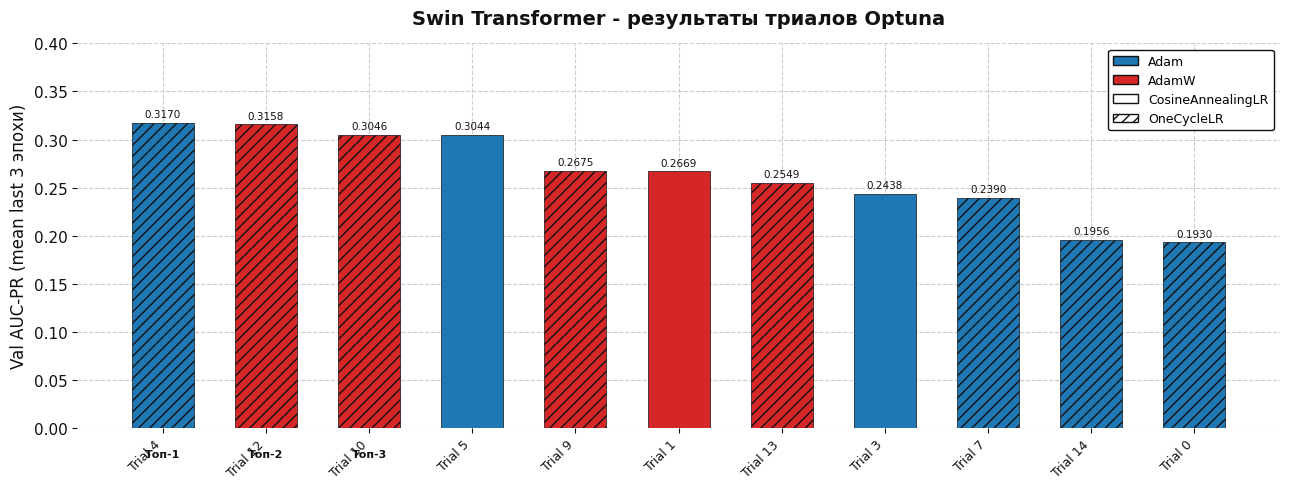

In [3]:
# График: результаты триалов Optuna, Swin Transformer

import numpy as np
from matplotlib.patches import Patch

trial_ids  = [4, 12, 10, 5, 9, 1, 13, 3, 7, 14, 0]
aucpr      = [0.3170, 0.3158, 0.3046, 0.3044, 0.2675, 0.2669, 0.2549, 0.2438, 0.2390, 0.1956, 0.1930]
optimizers = ['Adam', 'AdamW', 'AdamW', 'Adam', 'AdamW', 'AdamW', 'AdamW', 'Adam', 'Adam', 'Adam', 'Adam']
schedulers = ['OneCycleLR', 'OneCycleLR', 'OneCycleLR', 'CosineAnnealingLR', 'OneCycleLR',
              'CosineAnnealingLR', 'OneCycleLR', 'CosineAnnealingLR', 'OneCycleLR',
              'OneCycleLR', 'OneCycleLR']

color_map  = {'Adam': C1, 'AdamW': C2}
hatch_map  = {'OneCycleLR': '///', 'CosineAnnealingLR': ''}
bar_colors = [color_map[o] for o in optimizers]
hatches    = [hatch_map[s] for s in schedulers]

x = np.arange(len(trial_ids))

fig, ax = plt.subplots(figsize=(13, 5))

for i, (val, color, hatch) in enumerate(zip(aucpr, bar_colors, hatches)):
    ax.bar(i, val, color=color, hatch=hatch, edgecolor='#111111', linewidth=0.5, width=0.6)

for i, val in enumerate(aucpr):
    ax.text(i, val + 0.004, f'{val:.4f}', ha='center', va='bottom', fontsize=7.5, color='#111111')

for i in range(3):
    ax.text(i, -0.022, f'Топ-{i+1}', ha='center', va='top', fontsize=8, color='#111111', fontweight='bold')

legend_elements = [
    Patch(facecolor=C1, edgecolor='#111111', label='Adam'),
    Patch(facecolor=C2, edgecolor='#111111', label='AdamW'),
    Patch(facecolor='white', edgecolor='#111111', hatch='',    label='CosineAnnealingLR'),
    Patch(facecolor='white', edgecolor='#111111', hatch='///', label='OneCycleLR'),
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'Trial {t}' for t in trial_ids], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Val AUC-PR (mean last 3 эпохи)')
ax.set_title('Swin Transformer - результаты триалов Optuna')
ax.set_ylim(0, 0.40)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.savefig('swin_optuna_trials.png')
plt.show()

### Swin Transformer: подбор гиперпараметров через Optuna

**Топ-3 конфига по val AUC-PR:**
- Триал 4: AUC-PR = 0.3170, Adam + OneCycleLR, lr = 1.4e-5, wd = 2.30e-3, dropout = 0.105, label_smooth = 0.031
- Триал 12: AUC-PR = 0.3158, AdamW + OneCycleLR, lr = 2.0e-5, wd = 3.53e-4, dropout = 0.050, label_smooth = 0.000
- Триал 10: AUC-PR = 0.3046, AdamW + OneCycleLR, lr = 1.0e-5, wd = 1.11e-4, dropout = 0.000, label_smooth = 0.003

**Наблюдения:**
- OneCycleLR доминирует в топе - 8 из 11 триалов используют его, и все топ-3 конфига тоже. Swin Transformer с pretrained весами хорошо реагирует на прогрев lr в начале цикла, который OneCycleLR обеспечивает
- Лучшие lr очень маленькие (1.0e-5 - 2.0e-5) - типично для аккуратного дообучения трансформера с pretrained весами ImageNet-22k
- Топ-3 триала очень плотные (0.3046 - 0.3170) - пространство гиперпараметров в этой области однородное, все три конфига стоит проверить на длинном обучении
- Минимальный dropout и label_smoothing у победителей - Swin с pretrained весами не требует сильной регуляризации на этом датасете

**Вывод:** беру топ-3 триала на расширенное обучение.

---
## 5. Топ-3 конфигурации оптуны на 30 эпох

Беру 3 лучших завершённых (не обрезанных) trial из Optuna. Каждый обучаю на `NUM_EPOCHS_BLOCK2=30` эпох с нуля. После каждой модели сохраняю `.pth` (веса + optimizer + scheduler) и `.json` с метриками. Все метрики выводятся на каждой эпохе.  
**Итоговая метрика модели:** среднее val AUC-PR за последние 3 эпохи.  

In [21]:
import shutil

# Копирую базу Optuna из прошлой сессии в рабочую папку
shutil.copy(
    '/kaggle/input/datasets/sitnikovadarya/optuna-swin/optuna_swin.db',
    '/kaggle/working/optuna_swin.db'
)
print('База скопирована')

База скопирована


In [22]:
storage_url = 'sqlite:///' + STUDY_DB_PATH

pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=4)

study = optuna.load_study(
    study_name = STUDY_NAME,
    storage    = storage_url,
)

completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
print('Загружено trials: {} завершённых'.format(len(completed)))
print('Лучший: Trial #{} | value={:.4f}'.format(study.best_trial.number, study.best_trial.value))

Загружено trials: 11 завершённых
Лучший: Trial #4 | value=0.3170


In [23]:
# Выбираю топ-K завершённых trials
completed_trials = sorted(
    [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
    key=lambda t: t.value,
    reverse=True,
)

if len(completed_trials) == 0:
    raise RuntimeError('Нет завершённых trials.')

top_k_trials = completed_trials[:TOP_K]
print('Топ-{} конфигураций для обучения:'.format(TOP_K))
for rank, t in enumerate(top_k_trials):
    print('  Rank {}: Trial #{} | optuna_val_auc_pr={:.4f}'.format(rank + 1, t.number, t.value))

# Загружаю уже сохранённые результаты (защита от перезапуска)
block2_json_path = os.path.join(OUTPUT_DIR, 'block2_results.json')

if os.path.exists(block2_json_path):
    with open(block2_json_path, 'r', encoding='utf-8') as f:
        block2_results = json.load(f)
    print('\nЗагружены результаты предыдущего запуска: {} моделей'.format(len(block2_results)))
else:
    block2_results = []

Топ-3 конфигураций для обучения:
  Rank 1: Trial #4 | optuna_val_auc_pr=0.3170
  Rank 2: Trial #12 | optuna_val_auc_pr=0.3158
  Rank 3: Trial #10 | optuna_val_auc_pr=0.3046

Загружены результаты предыдущего запуска: 3 моделей


In [24]:
scaler = torch.cuda.amp.GradScaler()

# Обучаю каждую из топ-3 моделей
for rank, trial in enumerate(top_k_trials):
    trial_key  = 'trial_{}'.format(trial.number)
    rank_label = rank + 1  # 1, 2, 3

    # Проверяю, обучена ли уже эта модель в предыдущем запуске
    if any(r.get('trial_key') == trial_key for r in block2_results):
        print('\nRank {} (Trial #{}): уже обучена — пропускаю.'.format(
            rank_label, trial.number))
        continue

    params = trial.params
    print('\n' + '='*70)
    print('RANK {} | Trial #{} | Optuna val_auc_pr={:.4f}'.format(
        rank_label, trial.number, trial.value))
    print('Параметры: {}'.format(params))
    print('='*70)

    # Создаю модель, оптимизатор, планировщик, функцию потерь
    model     = make_swin(dropout=params['dropout']).to(DEVICE)
    optimizer = make_optimizer(params, model)
    scheduler = make_scheduler(params, optimizer, NUM_EPOCHS_BLOCK2, len(train_loader))
    criterion = LabelSmoothingBCELoss(label_smoothing=params['label_smoothing'])

    epoch_history      = []   # полная история всех метрик по эпохам
    val_auc_pr_history = []   # только AUC-PR для скользящего среднего

    for epoch in range(NUM_EPOCHS_BLOCK2):
        epoch_num = epoch + 1

        # Обучаю одну эпоху
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scheduler, scaler=scaler)

        # Все метрики на val (порог подбирается отдельно на каждой эпохе по F1)
        val_metrics = compute_metrics(model, val_loader, criterion=criterion, threshold=None)
        val_auc_pr_history.append(val_metrics['auc_pr'])

        # Скользящее среднее за последние 3 эпохи
        if epoch >= 2:
            sliding3     = float(np.mean(val_auc_pr_history[-3:]))
            sliding3_str = ' | sliding3={:.4f}'.format(sliding3)
        else:
            sliding3     = None
            sliding3_str = ''

        epoch_history.append({
            'epoch':            epoch_num,
            'train_loss':       round(train_loss, 6),
            'val_loss': round(val_metrics['loss'], 6),
            'val_auc_pr':       round(val_metrics['auc_pr'], 6),
            'val_f1':           round(val_metrics['f1'], 6),
            'val_recall':       round(val_metrics['recall'], 6),
            'val_precision':    round(val_metrics['precision'], 6),
            'val_specificity':  round(val_metrics['specificity'], 6),
            'val_balanced_acc': round(val_metrics['balanced_accuracy'], 6),
            'val_threshold':    round(val_metrics['threshold'], 4),
            'sliding_mean_3':   round(sliding3, 6) if sliding3 is not None else None,
        })

        # Вывод прогресса — все метрики на каждой эпохе
        print(
            'Ep {:2d}/{} | train_loss={:.4f} | val_loss={:.4f} | AUC-PR={:.4f} | F1={:.4f} | '
            'Rec={:.4f} | Prec={:.4f} | Spec={:.4f} | BalAcc={:.4f} | '
            'thr={:.2f}{}'.format(
                epoch_num, NUM_EPOCHS_BLOCK2,
                train_loss,
                val_metrics['loss'],
                val_metrics['auc_pr'],
                val_metrics['f1'],
                val_metrics['recall'],
                val_metrics['precision'],
                val_metrics['specificity'],
                val_metrics['balanced_accuracy'],
                val_metrics['threshold'],
                sliding3_str,
            )
        )

    # Ищу лучший порог на val — он будет применён к test
    final_val_metrics  = compute_metrics(model, val_loader, threshold=None)
    final_test_metrics = compute_metrics(model, test_loader,
                                         threshold=final_val_metrics['threshold'])

    mean_last3 = float(np.mean(val_auc_pr_history[-3:]))

    print('\nФинальные метрики (порог найден на val, применён к test):')
    print('  Val  | AUC-PR={:.4f} | F1={:.4f} | Rec={:.4f} | '
          'Prec={:.4f} | Spec={:.4f} | BalAcc={:.4f} | thr={:.2f}'.format(
        final_val_metrics['auc_pr'], final_val_metrics['f1'],
        final_val_metrics['recall'], final_val_metrics['precision'],
        final_val_metrics['specificity'], final_val_metrics['balanced_accuracy'],
        final_val_metrics['threshold']))
    print('  Test | AUC-PR={:.4f} | F1={:.4f} | Rec={:.4f} | '
          'Prec={:.4f} | Spec={:.4f} | BalAcc={:.4f}'.format(
        final_test_metrics['auc_pr'], final_test_metrics['f1'],
        final_test_metrics['recall'], final_test_metrics['precision'],
        final_test_metrics['specificity'], final_test_metrics['balanced_accuracy']))
    print('  Итоговая метрика (mean last-3 val AUC-PR): {:.4f}'.format(mean_last3))

    # Сохраняю чекпоинт
    ckpt_filename = 'block2_rank{}_trial{}.pth'.format(rank_label, trial.number)
    ckpt_path     = os.path.join(OUTPUT_DIR, ckpt_filename)
    torch.save({
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'params':               params,
        'val_auc_pr_history':   val_auc_pr_history,
        'epoch':                NUM_EPOCHS_BLOCK2,
        'trial_number':         trial.number,
        'rank':                 rank_label,
    }, ckpt_path)
    print('Веса сохранены:', ckpt_path)
    ipd.display(ipd.FileLink(ckpt_path))

    # Записываю результат в список
    def round_metrics(d):
        return {k: round(v, 6) if isinstance(v, float) else v for k, v in d.items()}

    block2_results.append({
        'trial_key':             trial_key,
        'rank':                  rank_label,
        'trial_number':          trial.number,
        'optuna_value':          round(trial.value, 6),
        'params':                params,
        'epoch_history':         epoch_history,
        'mean_last3_val_auc_pr': round(mean_last3, 6),
        'final_val_metrics':     round_metrics(final_val_metrics),
        'final_test_metrics':    round_metrics(final_test_metrics),
        'checkpoint_path':       ckpt_path,
    })

    # Сохраняю JSON сразу после каждой модели
    save_results(block2_results, block2_json_path)

    # Освобождаю GPU-память
    del model, optimizer, scheduler, criterion
    torch.cuda.empty_cache()


Rank 1 (Trial #4): уже обучена — пропускаю.

Rank 2 (Trial #12): уже обучена — пропускаю.

Rank 3 (Trial #10): уже обучена — пропускаю.


In [6]:
with open('/kaggle/working/block2_results.json', 'r') as f:
    results = json.load(f)

# --- Вывод метрик в читаемом формате ---
for entry in sorted(results, key=lambda x: x['rank']):
    rank        = entry['rank']
    trial       = entry['trial_number']
    mean_last3  = entry['mean_last3_val_auc_pr']
    params      = entry['params']
    val         = entry['final_val_metrics']
    test        = entry['final_test_metrics']

    print(f"{'='*70}")
    print(f"RANK {rank} | Trial #{trial} | mean_last3_val_auc_pr={mean_last3:.4f}")
    print(f"Параметры: {params}")
    print(f"  Val  | AUC-PR={val['auc_pr']:.4f} | F1={val['f1']:.4f} | Rec={val['recall']:.4f} | Prec={val['precision']:.4f} | Spec={val['specificity']:.4f} | BalAcc={val['balanced_accuracy']:.4f} | thr={val['threshold']:.2f}")
    print(f"  Test | AUC-PR={test['auc_pr']:.4f} | F1={test['f1']:.4f} | Rec={test['recall']:.4f} | Prec={test['precision']:.4f} | Spec={test['specificity']:.4f} | BalAcc={test['balanced_accuracy']:.4f}")
    print(f"  Итоговая метрика (mean last-3 val AUC-PR): {mean_last3:.4f}")

RANK 1 | Trial #4 | mean_last3_val_auc_pr=0.2402
Параметры: {'optimizer': 'Adam', 'scheduler': 'OneCycleLR', 'lr': 1.415460709340741e-05, 'weight_decay': 0.0022976032930297607, 'dropout': 0.10463489073634867, 'label_smoothing': 0.03105484189790111}
  Val  | AUC-PR=0.2389 | F1=0.3652 | Rec=0.2877 | Prec=0.5000 | Spec=0.9948 | BalAcc=0.6413 | thr=0.47
  Test | AUC-PR=0.2634 | F1=0.3134 | Rec=0.2877 | Prec=0.3443 | Spec=0.9902 | BalAcc=0.6389
  Итоговая метрика (mean last-3 val AUC-PR): 0.2402
RANK 2 | Trial #12 | mean_last3_val_auc_pr=0.2419
Параметры: {'optimizer': 'AdamW', 'scheduler': 'OneCycleLR', 'lr': 2.0104711334324793e-05, 'weight_decay': 0.0003532862931020622, 'dropout': 0.0496065160662286, 'label_smoothing': 0.0003282156496044208}
  Val  | AUC-PR=0.2412 | F1=0.3308 | Rec=0.3014 | Prec=0.3667 | Spec=0.9907 | BalAcc=0.6460 | thr=0.02
  Test | AUC-PR=0.2410 | F1=0.3724 | Rec=0.3699 | Prec=0.3750 | Spec=0.9889 | BalAcc=0.6794
  Итоговая метрика (mean last-3 val AUC-PR): 0.2419
RANK

In [25]:
# Итоговая таблица сравнения трёх моделей
print('\n' + '='*80)
print('ИТОГИ ЧАСТИ 5: СРАВНЕНИЕ ТОП-3 КОНФИГУРАЦИЙ')
print('='*80)

header = '{:<5} {:<10} {:<20} {:<12} {:<12} {:<12} {:<10}'.format(
    'Rank', 'Trial#', 'mean_last3_AUC-PR', 'Val AUC-PR', 'Test AUC-PR',
    'Test Recall', 'Test F1'
)
print(header)
print('-'*80)

for r in sorted(block2_results, key=lambda x: x['mean_last3_val_auc_pr'], reverse=True):
    print('{:<5} {:<10} {:<20.4f} {:<12.4f} {:<12.4f} {:<12.4f} {:<10.4f}'.format(
        r['rank'],
        r['trial_number'],
        r['mean_last3_val_auc_pr'],
        r['final_val_metrics']['auc_pr'],
        r['final_test_metrics']['auc_pr'],
        r['final_test_metrics']['recall'],
        r['final_test_metrics']['f1'],
    ))

best_b2 = max(block2_results, key=lambda r: r['mean_last3_val_auc_pr'])
print('\nЛучший по mean_last3_val_auc_pr:')
print('  Rank={} | Trial={} | mean_last3={:.4f} | Параметры: {}'.format(
    best_b2['rank'], best_b2['trial_number'],
    best_b2['mean_last3_val_auc_pr'], best_b2['params']))


ИТОГИ ЧАСТИ 5: СРАВНЕНИЕ ТОП-3 КОНФИГУРАЦИЙ
Rank  Trial#     mean_last3_AUC-PR    Val AUC-PR   Test AUC-PR  Test Recall  Test F1   
--------------------------------------------------------------------------------
3     10         0.2937               0.2944       0.2519       0.3014       0.3520    
2     12         0.2419               0.2412       0.2410       0.3699       0.3724    
1     4          0.2402               0.2389       0.2634       0.2877       0.3134    

Лучший по mean_last3_val_auc_pr:
  Rank=3 | Trial=10 | mean_last3=0.2937 | Параметры: {'optimizer': 'AdamW', 'scheduler': 'OneCycleLR', 'lr': 1.0370509067047067e-05, 'weight_decay': 0.00011142229399166472, 'dropout': 0.0004582024828691522, 'label_smoothing': 0.002931760956307424}


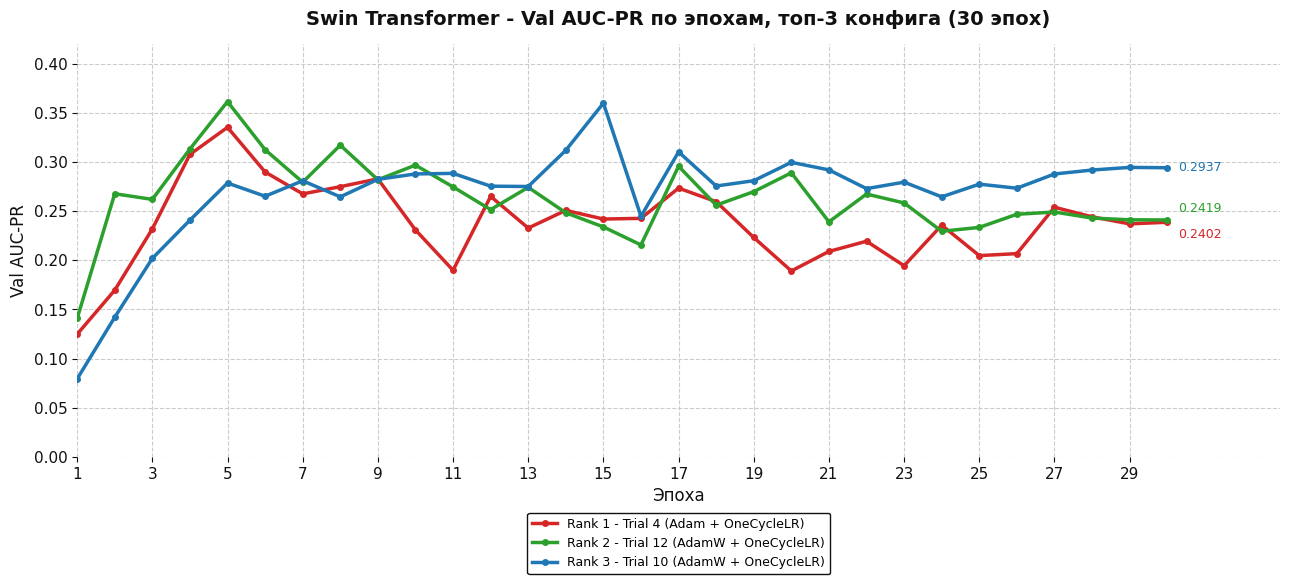

In [9]:
# График 1: val AUC-PR по эпохам для топ-3

fig, ax = plt.subplots(figsize=(13, 6))

rank_colors = {1: C2, 2: C3, 3: C1}

for entry in sorted(results, key=lambda x: x['rank']):
    rank   = entry['rank']
    trial  = entry['trial_number']
    color  = rank_colors[rank]
    epochs = [ep['epoch'] for ep in entry['epoch_history']]
    vals   = [ep['val_auc_pr'] for ep in entry['epoch_history']]
    mean_last3 = entry['mean_last3_val_auc_pr']
    opt    = entry['params']['optimizer']
    sched  = entry['params']['scheduler']

    ax.plot(epochs, vals, color=color, marker='o', markersize=4,
            label=f"Rank {rank} - Trial {trial} ({opt} + {sched})")
    if rank == 1:
        y_text = vals[-1] - 0.012
    elif rank == 2:
        y_text = vals[-1] + 0.012
    else:
        y_text = vals[-1]

    ax.annotate(f"{mean_last3:.4f}", xy=(epochs[-1], vals[-1]),
                xytext=(epochs[-1] + 0.3, y_text),
                fontsize=9, color=color, va='center')

ax.set_xlabel('Эпоха')
ax.set_ylabel('Val AUC-PR')
ax.set_title('Swin Transformer - Val AUC-PR по эпохам, топ-3 конфига (30 эпох)')
ax.set_xticks(list(range(1, 31, 2)))
ax.set_xlim(1, 33)
ax.set_ylim(0, 0.42)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), frameon=True, fontsize=9, ncol=1)
plt.tight_layout()
plt.savefig('swin_top3_val_aucpr.png')
plt.show()

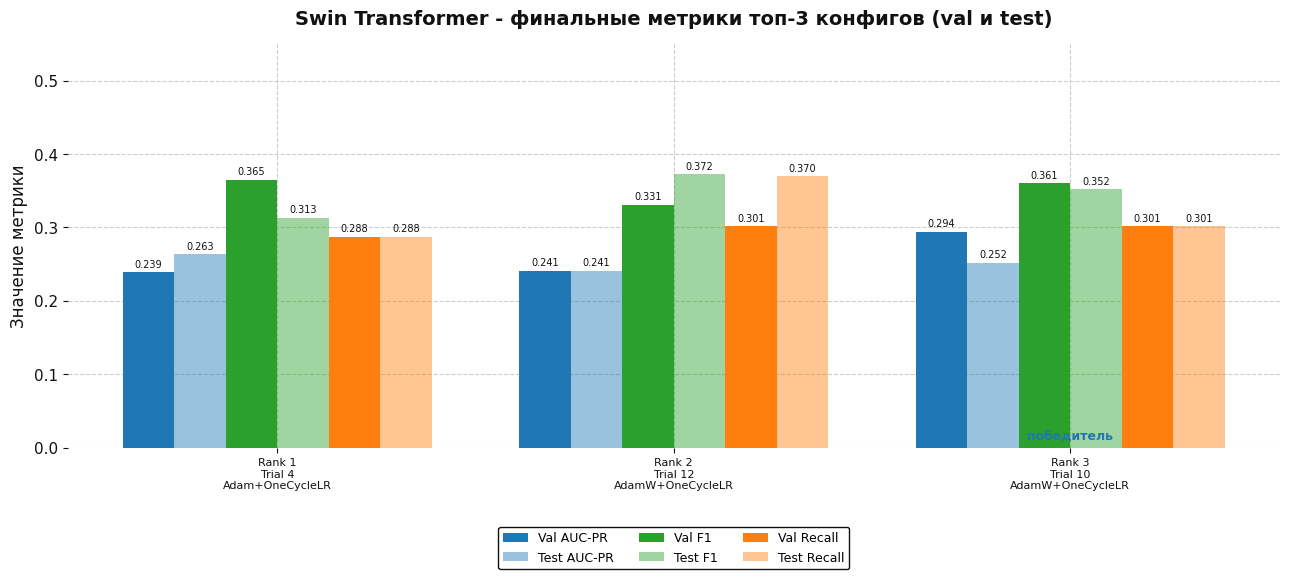

In [8]:
# График 2: столбчатый - val и test AUC-PR, F1, Recall для топ-3

entries_sorted = sorted(results, key=lambda x: x['rank'])

configs    = [f"Rank {e['rank']}\nTrial {e['trial_number']}\n{e['params']['optimizer']}+{e['params']['scheduler'].replace('AnnealingLR','').replace('Cycle','Cycle')}" for e in entries_sorted]
val_aucpr  = [e['final_val_metrics']['auc_pr']  for e in entries_sorted]
test_aucpr = [e['final_test_metrics']['auc_pr'] for e in entries_sorted]
val_f1     = [e['final_val_metrics']['f1']      for e in entries_sorted]
test_f1    = [e['final_test_metrics']['f1']     for e in entries_sorted]
val_rec    = [e['final_val_metrics']['recall']  for e in entries_sorted]
test_rec   = [e['final_test_metrics']['recall'] for e in entries_sorted]

x     = np.arange(len(configs))
width = 0.13

fig, ax = plt.subplots(figsize=(13, 6))

bars = [
    ax.bar(x - 2.5*width, val_aucpr,  width, label='Val AUC-PR',  color=C1),
    ax.bar(x - 1.5*width, test_aucpr, width, label='Test AUC-PR', color=C1, alpha=0.45),
    ax.bar(x - 0.5*width, val_f1,     width, label='Val F1',      color=C3),
    ax.bar(x + 0.5*width, test_f1,    width, label='Test F1',     color=C3, alpha=0.45),
    ax.bar(x + 1.5*width, val_rec,    width, label='Val Recall',  color=C4),
    ax.bar(x + 2.5*width, test_rec,   width, label='Test Recall', color=C4, alpha=0.45),
]

for bar_group in bars:
    for bar in bar_group:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.004,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7, color='#111111')

ax.text(2, 0.01, 'победитель', ha='center', fontsize=9, color=C1, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(configs, fontsize=8)
ax.set_ylabel('Значение метрики')
ax.set_title('Swin Transformer - финальные метрики топ-3 конфигов (val и test)')
ax.set_ylim(0, 0.55)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), frameon=True, fontsize=9, ncol=3)
plt.tight_layout()
plt.savefig('swin_top3_metrics_bar.png')
plt.show()

---
## 6. Дообучение лучшей модели

Беру лучшую из топ-3 по **среднему val AUC-PR за последние 3 эпохи** из прошлой части. Загружаю её веса, optimizer и scheduler из чекпоинта части 5.  

**Критерий сохранения лучших весов:** максимальное скользящее среднее val AUC-PR за последние 3 эпохи из общей истории.  

**Early stopping:** patience=7 эпох без улучшения скользящего среднего. Счётчик ведётся от лучшего значения за **всё время** (включая предыдущую часть).  

**Первые 2 эпохи части 6 (глобально 21–22):** не сохраняю и не считаю patience. С 23-ей эпохи скользящее окно `[-3:]` заполнено только новыми эпохами.   

**Итоговая метрика для отчёта:** среднее val AUC-PR за последние 3 эпохи.

In [26]:
# Выбираю лучшую модель из топ-3 по среднему AUC-PR
best_b2 = max(block2_results, key=lambda r: r['mean_last3_val_auc_pr'])
print('Лучшая модель из части 5:')
print('  Rank={} | Trial={} | mean_last3_val_auc_pr={:.4f}'.format(
    best_b2['rank'], best_b2['trial_number'], best_b2['mean_last3_val_auc_pr']))
print('  Параметры: {}'.format(best_b2['params']))
print('  Загружаю из: {}'.format(best_b2['checkpoint_path']))

checkpoint = torch.load(best_b2['checkpoint_path'], map_location=DEVICE)
params     = checkpoint['params']

# Восстанавливаю модель с теми же параметрами, что в части 5
model = make_swin(dropout=params['dropout']).to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])

# Восстанавливаю оптимизатор
optimizer = make_optimizer(params, model)
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# Перемещаю оптимизатор на нужное устройство
for state in optimizer.state.values():
    for k, v in state.items():
        if isinstance(v, torch.Tensor):
            state[k] = v.to(DEVICE)

# Восстанавливаю scheduler и продолжаю с того места, где остановились в части 5
scheduler = make_scheduler(params, optimizer, NUM_EPOCHS_BLOCK3, len(train_loader))
if params['scheduler'] == 'OneCycleLR':
    print('Scheduler OneCycleLR: начинаю новый цикл на {} эпох.'.format(NUM_EPOCHS_BLOCK3))
else:
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    print('Scheduler {} загружен из checkpoint.'.format(params['scheduler']))
criterion = LabelSmoothingBCELoss(label_smoothing=params['label_smoothing'])

# Инициализируем early stopping
# История AUC-PR из части 5 нужна, чтобы скользящее окно корректно работало
val_auc_pr_history = checkpoint['val_auc_pr_history']
print('Загружена история части 5, ({} эпох).'.format(len(val_auc_pr_history)))

# Начальное лучшее скользящее среднее из конца части 5
best_sliding_mean = float(np.mean(val_auc_pr_history[-3:]))
best_weights      = copy.deepcopy(model.state_dict())
patience_counter  = 0
best_epoch_global = NUM_EPOCHS_BLOCK2

print('Начальное лучшее скользящее среднее (конец части 5): {:.4f}'.format(best_sliding_mean))
print('Дообучаю {} эпох с early stopping (patience={}).\n'.format(
    NUM_EPOCHS_BLOCK3, EARLY_STOPPING_PATIENCE))

block3_epoch_history = []
early_stopped        = False

scaler = torch.cuda.amp.GradScaler()

for epoch in range(NUM_EPOCHS_BLOCK3):
    epoch_local  = epoch + 1
    epoch_global = NUM_EPOCHS_BLOCK2 + epoch + 1

    # Обучаю одну эпоху
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scheduler, scaler=scaler)

    # Все метрики на val
    val_metrics = compute_metrics(model, val_loader, criterion=criterion, threshold=None)
    val_auc_pr_history.append(val_metrics['auc_pr'])

    # Скользящее среднее за крайние 3 эпохи
    sliding_mean = float(np.mean(val_auc_pr_history[-3:]))

    # Звёздочкой отмечаю лучшее значение
    star = ''
    if epoch >= 2 and sliding_mean > best_sliding_mean:
        star = ' BEST'

    print(
        'Ep {:2d}/{} (glob {:2d}) | train_loss={:.4f} | val_loss={:.4f} | AUC-PR={:.4f} | F1={:.4f} | '
        'Rec={:.4f} | Prec={:.4f} | Spec={:.4f} | BalAcc={:.4f} | '
        'thr={:.2f} | AVG_3 AUC-PR={:.4f}{}'.format(
            int(epoch_local), int(NUM_EPOCHS_BLOCK3), int(epoch_global),
            train_loss,
            val_metrics['loss'],
            val_metrics['auc_pr'],
            val_metrics['f1'],
            val_metrics['recall'],
            val_metrics['precision'],
            val_metrics['specificity'],
            val_metrics['balanced_accuracy'],
            val_metrics['threshold'],
            sliding_mean,
            star,
        )
    )

    block3_epoch_history.append({
        'epoch_local':       epoch_local,
        'epoch_global':      epoch_global,
        'train_loss':        round(train_loss, 6),
        'val_loss':          round(val_metrics['loss'], 6),
        'val_auc_pr':        round(val_metrics['auc_pr'], 6),
        'val_f1':            round(val_metrics['f1'], 6),
        'val_recall':        round(val_metrics['recall'], 6),
        'val_precision':     round(val_metrics['precision'], 6),
        'val_specificity':   round(val_metrics['specificity'], 6),
        'val_balanced_acc':  round(val_metrics['balanced_accuracy'], 6),
        'val_threshold':     round(val_metrics['threshold'], 4),
        'sliding_mean_3':    round(sliding_mean, 6),
    })

    # Early stopping
    if epoch >= 2:
        if sliding_mean > best_sliding_mean:
            # Нашла лучшее скользящее среднее — сохраняю веса, сбрасываю терпение
            best_sliding_mean  = sliding_mean
            best_weights       = copy.deepcopy(model.state_dict())
            best_epoch_global  = epoch_global
            patience_counter   = 0
        else:
            patience_counter += 1

        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print('\nEarly stopping: {} эпох без улучшения.'.format(
                EARLY_STOPPING_PATIENCE))
            print('Лучшие веса: глобальная эпоха {}.'.format(best_epoch_global))
            early_stopped = True
            break

# Загружаю лучшие веса
model.load_state_dict(best_weights)
print('\nЗагружены лучшие веса (глобальная эпоха {}).'.format(best_epoch_global))
print('Лучшее скользящее среднее val AUC-PR: {:.4f}'.format(best_sliding_mean))

Лучшая модель из части 5:
  Rank=3 | Trial=10 | mean_last3_val_auc_pr=0.2937
  Параметры: {'optimizer': 'AdamW', 'scheduler': 'OneCycleLR', 'lr': 1.0370509067047067e-05, 'weight_decay': 0.00011142229399166472, 'dropout': 0.0004582024828691522, 'label_smoothing': 0.002931760956307424}
  Загружаю из: /kaggle/working/block2_rank3_trial10.pth


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Scheduler OneCycleLR: начинаю новый цикл на 20 эпох.
Загружена история части 5, (30 эпох).
Начальное лучшее скользящее среднее (конец части 5): 0.2937
Дообучаю 20 эпох с early stopping (patience=7).

Ep  1/20 (glob 31) | train_loss=0.0156 | val_loss=0.1009 | AUC-PR=0.3031 | F1=0.3676 | Rec=0.3425 | Prec=0.3968 | Spec=0.9907 | BalAcc=0.6666 | thr=0.11 | AVG_3 AUC-PR=0.2974
Ep  2/20 (glob 32) | train_loss=0.0156 | val_loss=0.1032 | AUC-PR=0.2814 | F1=0.3680 | Rec=0.3151 | Prec=0.4423 | Spec=0.9929 | BalAcc=0.6540 | thr=0.22 | AVG_3 AUC-PR=0.2930
Ep  3/20 (glob 33) | train_loss=0.0180 | val_loss=0.1059 | AUC-PR=0.2800 | F1=0.3867 | Rec=0.3973 | Prec=0.3766 | Spec=0.9882 | BalAcc=0.6927 | thr=0.18 | AVG_3 AUC-PR=0.2882
Ep  4/20 (glob 34) | train_loss=0.0214 | val_loss=0.1089 | AUC-PR=0.3044 | F1=0.3846 | Rec=0.4110 | Prec=0.3614 | Spec=0.9870 | BalAcc=0.6990 | thr=0.60 | AVG_3 AUC-PR=0.2886
Ep  5/20 (glob 35) | train_loss=0.0248 | val_loss=0.1077 | AUC-PR=0.2544 | F1=0.3566 | Rec=0.3151 | 

In [27]:
# Финальные метрики и сохранение результатов

# Порог подбираю на val с лучшими весами, применяем на test
final_val_metrics  = compute_metrics(model, val_loader,  criterion=criterion, threshold=None)
final_test_metrics = compute_metrics(model, test_loader, criterion=criterion,
                                     threshold=final_val_metrics['threshold'])

# Итоговая метрика для отчёта: среднее AUC-PR за последние 3 эпохи
last3_auc_pr      = [r['val_auc_pr'] for r in block3_epoch_history[-3:]]
mean_last3_block3 = float(np.mean(last3_auc_pr))

print('\n' + '='*70)
print('ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ЧАСТИ 6')
print('='*70)
print('Эпох дообучения: {} из {} | Early stopping: {}'.format(
    len(block3_epoch_history), NUM_EPOCHS_BLOCK3, early_stopped))
print('Лучшие веса: глобальная эпоха {}'.format(best_epoch_global))
print('Лучшее скользящее среднее val AUC-PR: {:.4f}'.format(best_sliding_mean))
print('Итоговая метрика (mean last-3 val AUC-PR ЧАСТИ 6): {:.4f}'.format(mean_last3_block3))

print('\nVal-метрики (порог={:.2f}):'.format(final_val_metrics['threshold']))
print('  AUC-PR={:.4f} | F1={:.4f} | Recall={:.4f} | Precision={:.4f} | '
      'Specificity={:.4f} | BalAcc={:.4f}'.format(
    final_val_metrics['auc_pr'],  final_val_metrics['f1'],
    final_val_metrics['recall'],  final_val_metrics['precision'],
    final_val_metrics['specificity'], final_val_metrics['balanced_accuracy']))

print('\nTest-метрики (порог с val={:.2f}):'.format(final_val_metrics['threshold']))
print('  AUC-PR={:.4f} | F1={:.4f} | Recall={:.4f} | Precision={:.4f} | '
      'Specificity={:.4f} | BalAcc={:.4f}'.format(
    final_test_metrics['auc_pr'],  final_test_metrics['f1'],
    final_test_metrics['recall'],  final_test_metrics['precision'],
    final_test_metrics['specificity'], final_test_metrics['balanced_accuracy']))

# Сохраняю веса финальной модели
final_model_path = os.path.join(OUTPUT_DIR, 'block3_final_model.pth')
torch.save({
    'model_state_dict':           best_weights,
    'params':                     params,
    'best_epoch_global':          best_epoch_global,
    'best_sliding_mean':          best_sliding_mean,
    'val_auc_pr_history_full':    val_auc_pr_history,
    'early_stopped':              early_stopped,
}, final_model_path)
print('\nВеса финальной модели сохранены:', final_model_path)
ipd.display(ipd.FileLink(final_model_path))

# Сохраняю результаты в JSON
def round_metrics(d):
    return {k: round(v, 6) if isinstance(v, float) else v for k, v in d.items()}

block3_results = [{
    'source_trial_number':          best_b2['trial_number'],
    'source_rank':                  best_b2['rank'],
    'params':                       params,
    'epochs_run_block3':            len(block3_epoch_history),
    'early_stopped':                early_stopped,
    'best_epoch_global':            best_epoch_global,
    'best_sliding_mean_val_auc_pr': round(best_sliding_mean, 6),
    'mean_last3_val_auc_pr_block3': round(mean_last3_block3, 6),
    'epoch_history_block3':         block3_epoch_history,
    'final_val_metrics':            round_metrics(final_val_metrics),
    'final_test_metrics':           round_metrics(final_test_metrics),
    'model_path':                   final_model_path,
}]

block3_json_path = os.path.join(OUTPUT_DIR, 'block3_results.json')
save_results(block3_results, block3_json_path)

print('\nФинальная модель обучена и сохранена.')


ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ЧАСТИ 6
Эпох дообучения: 9 из 20 | Early stopping: True
Лучшие веса: глобальная эпоха 30
Лучшее скользящее среднее val AUC-PR: 0.2937
Итоговая метрика (mean last-3 val AUC-PR ЧАСТИ 6): 0.2452

Val-метрики (порог=0.39):
  AUC-PR=0.2944 | F1=0.3607 | Recall=0.3014 | Precision=0.4490 | Specificity=0.9934 | BalAcc=0.6474

Test-метрики (порог с val=0.39):
  AUC-PR=0.2519 | F1=0.3520 | Recall=0.3014 | Precision=0.4231 | Specificity=0.9926 | BalAcc=0.6470

Веса финальной модели сохранены: /kaggle/working/block3_final_model.pth


/kaggle/working/block3_final_model.pth

Сохранено: /kaggle/working/block3_results.json


/kaggle/working/block3_results.json


Финальная модель обучена и сохранена.


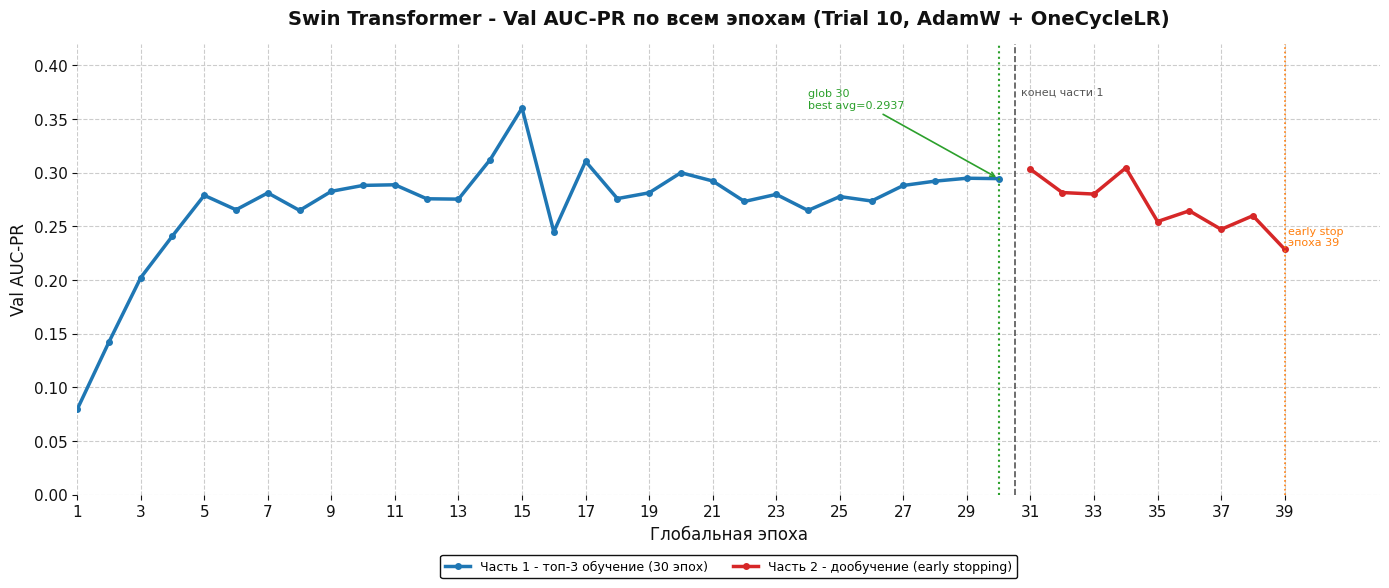

In [10]:
# График 1: сквозной val AUC-PR, Swin Transformer - эпохи 1-39

# Данные части 1 берём из JSON
entry_winner = next(e for e in results if e['rank'] == 3)
val_aucpr_p1 = [ep['val_auc_pr'] for ep in entry_winner['epoch_history']]
epochs_p1    = list(range(1, 31))

epochs_p2    = list(range(31, 40))
val_aucpr_p2 = [0.3031, 0.2814, 0.2800, 0.3044, 0.2544, 0.2644, 0.2471, 0.2598, 0.2286]

val_aucpr_all = val_aucpr_p1 + val_aucpr_p2

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(epochs_p1, val_aucpr_p1, color=C1, marker='o', markersize=4, label='Часть 1 - топ-3 обучение (30 эпох)')
ax.plot(epochs_p2, val_aucpr_p2, color=C2, marker='o', markersize=4, label='Часть 2 - дообучение (early stopping)')

# Граница между частями
ax.axvline(30.5, color=C_GRAY, linewidth=1.2, linestyle='--')
ax.text(30.7, 0.38, 'конец части 1', fontsize=8, color=C_GRAY, va='top')

# Лучшая эпоха - glob 30, последняя эпоха части 1
ax.axvline(30, color=C3, linewidth=1.5, linestyle=':')
ax.annotate('glob 30\nbest avg=0.2937',
            xy=(30, val_aucpr_all[29]), xytext=(24, 0.36),
            arrowprops=dict(arrowstyle='->', color=C3, lw=1.2),
            fontsize=8, color=C3)

# Early stopping
ax.axvline(39, color=C4, linewidth=1.2, linestyle=':')
ax.text(39.1, 0.24, 'early stop\nэпоха 39', fontsize=8, color=C4, va='center')

ax.set_xlabel('Глобальная эпоха')
ax.set_ylabel('Val AUC-PR')
ax.set_title('Swin Transformer - Val AUC-PR по всем эпохам (Trial 10, AdamW + OneCycleLR)')
ax.set_xticks(list(range(1, 40, 2)))
ax.set_xlim(1, 42)
ax.set_ylim(0, 0.42)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), frameon=True, fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('swin_full_val_aucpr.png')
plt.show()

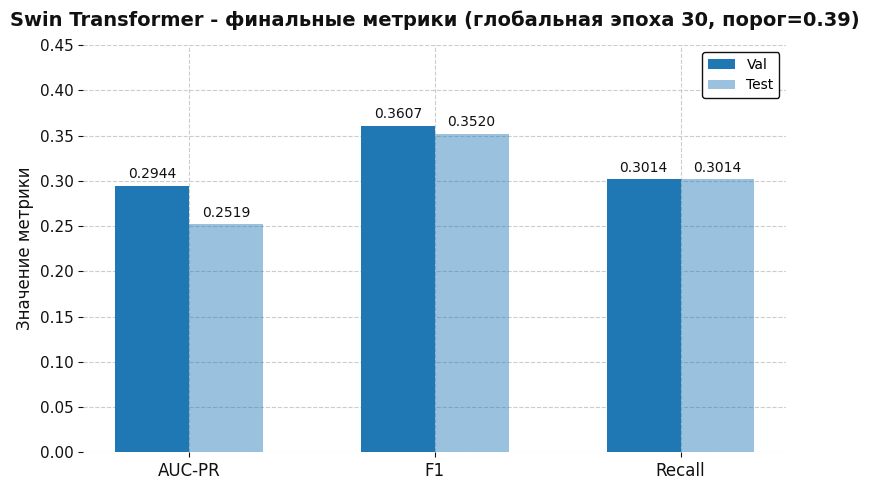

In [11]:
# График 2: столбчатый - val vs test, Swin Transformer финальные метрики

import numpy as np

metrics   = ['AUC-PR', 'F1', 'Recall']
val_vals  = [0.2944, 0.3607, 0.3014]
test_vals = [0.2519, 0.3520, 0.3014]

x     = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))

bars_val  = ax.bar(x - width/2, val_vals,  width, label='Val',  color=C1)
bars_test = ax.bar(x + width/2, test_vals, width, label='Test', color=C1, alpha=0.45)

for bars in [bars_val, bars_test]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.4f}', ha='center', va='bottom', fontsize=10, color='#111111')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Значение метрики')
ax.set_title('Swin Transformer - финальные метрики (глобальная эпоха 30, порог=0.39)')
ax.set_ylim(0, 0.45)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(frameon=True, fontsize=10)
plt.tight_layout()
plt.savefig('swin_final_metrics_bar.png')
plt.show()

### Swin Transformer: дообучение победителя до 20 эпох

Обучение остановилось уже на глобальной эпохе 39 - модель не смогла превысить результат конца части 1. Лучшие веса зафиксированы на глобальной эпохе 30 (последняя эпоха части 1, avg=0.2937) - дообучение не дало прироста.

**Финальные метрики (порог=0.39, найден на val):**
- Val: AUC-PR=0.2944, F1=0.3607, Recall=0.3014
- Test: AUC-PR=0.2519, F1=0.3520, Recall=0.3014

Val и test Recall совпадают (0.3014) - порог хорошо перенёсся. Test AUC-PR ниже val (0.2519 vs 0.2944), что типично для задачи с сильным дисбалансом классов.